In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy

from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier


In [2]:
def drop_unnecessary(df: pd.DataFrame) -> pd.DataFrame:
    return df.drop(columns=["native-country", "education", "marital-status", "relationship", "race", "sex", "capital-loss", "capital-gain"])

In [3]:
base_adult = pd.read_csv(filepath_or_buffer="adult\\adult.data")
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [4]:
base_adult["income"].value_counts()

income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [5]:
7841/32561

0.2408095574460244

Age analysis

In [6]:
base_adult["age"].describe()

count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

<Axes: xlabel='age', ylabel='Count'>

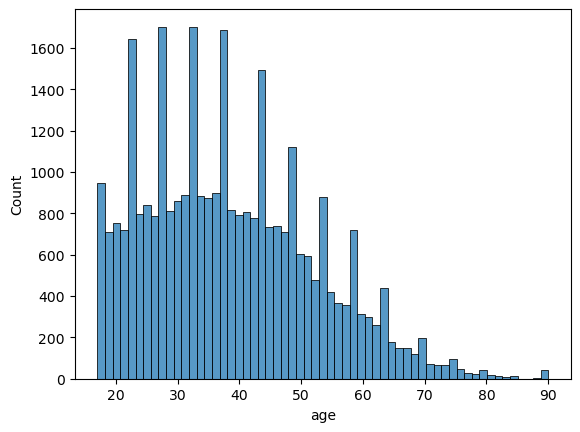

In [7]:
sns.histplot(data=base_adult["age"])

In [8]:
# 16% of people up to 40yo have a networth above 50K (19.118 samples)
base_adult[base_adult.age <= 40]["income"].value_counts()

income
<=50K    16030
>50K      3088
Name: count, dtype: int64

In [9]:
# 37% of people on (40, 60]yo have a networth of 50k (11111 samples)
base_adult[(base_adult.age > 40) & (base_adult.age <= 60)]["income"].value_counts()

income
<=50K    6909
>50K     4202
Name: count, dtype: int64

In [10]:
# 23% of people above 69yo have a networth of 50k (2332 samples)
base_adult[base_adult.age > 60]["income"].value_counts()

income
<=50K    1781
>50K      551
Name: count, dtype: int64

applying normalization technique as suggested on https://www.datacamp.com/tutorial/normalization-vs-standardization

In [11]:
age_min_max_scaler = MinMaxScaler()
base_adult["age"] = age_min_max_scaler.fit_transform(pd.DataFrame(base_adult["age"]))
base_adult

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.301370,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,0.452055,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,0.287671,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,0.493151,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,0.150685,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.136986,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,0.315068,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,0.561644,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,0.068493,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


<h5>Native country analysis</h5>

<Axes: xlabel='count', ylabel='native-country'>

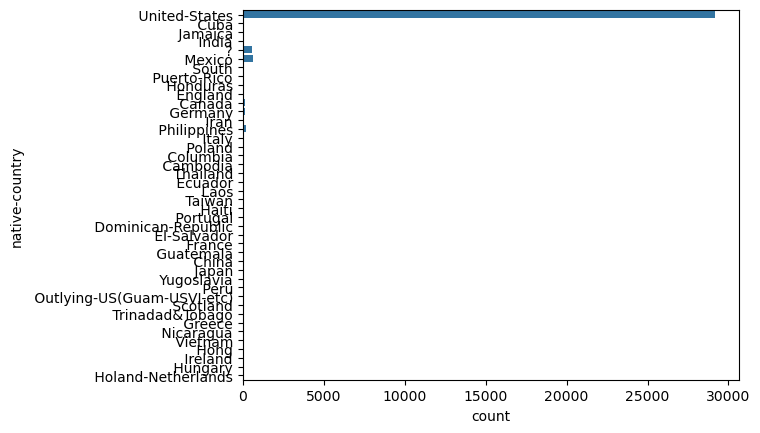

In [12]:
sns.countplot(base_adult["native-country"])

In [13]:
np.unique(base_adult["income"], return_counts=True)

(array([' <=50K', ' >50K'], dtype=object), array([24720,  7841]))

<Axes: xlabel='income', ylabel='count'>

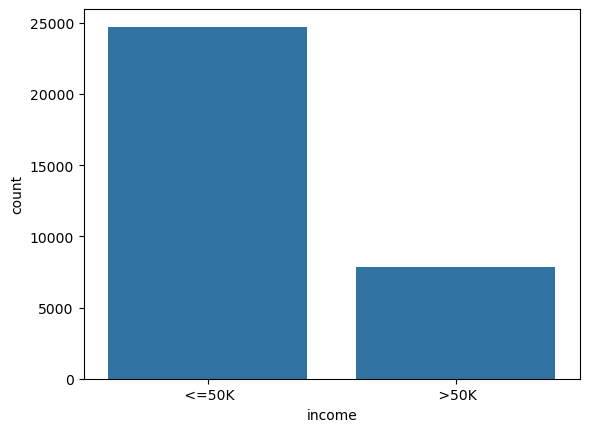

In [14]:
sns.countplot(x=base_adult["income"])

(array([5570., 5890., 6048., 6163., 3967., 2591., 1595.,  496.,  174.,
          67.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

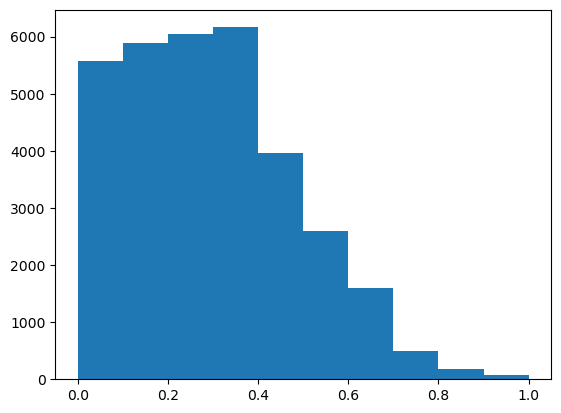

In [15]:
plt.hist(x=base_adult["age"])

(array([  219.,   333.,  1160.,   933.,  1608., 10501.,  8673.,  1067.,
         7078.,   989.]),
 array([ 1. ,  2.5,  4. ,  5.5,  7. ,  8.5, 10. , 11.5, 13. , 14.5, 16. ]),
 <BarContainer object of 10 artists>)

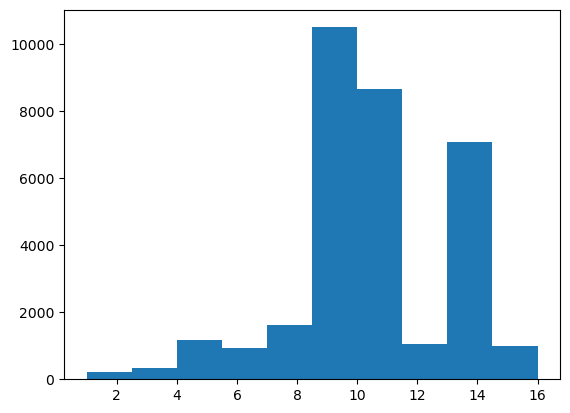

In [16]:
plt.hist(x=base_adult["education-num"])

<Axes: xlabel='count', ylabel='education'>

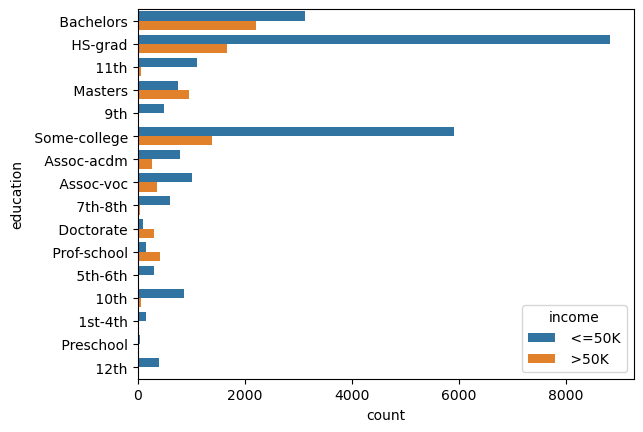

In [17]:
sns.countplot(y=base_adult["education"], hue=base_adult["income"])

<Axes: xlabel='count', ylabel='marital-status'>

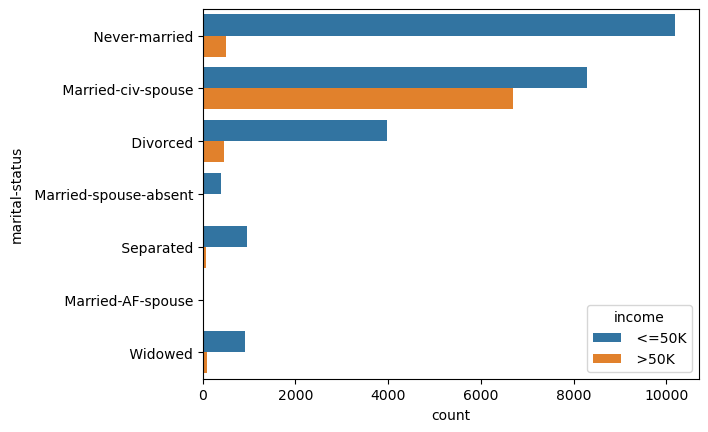

In [18]:
sns.countplot(y=base_adult["marital-status"], hue=base_adult["income"])

<Axes: xlabel='count', ylabel='workclass'>

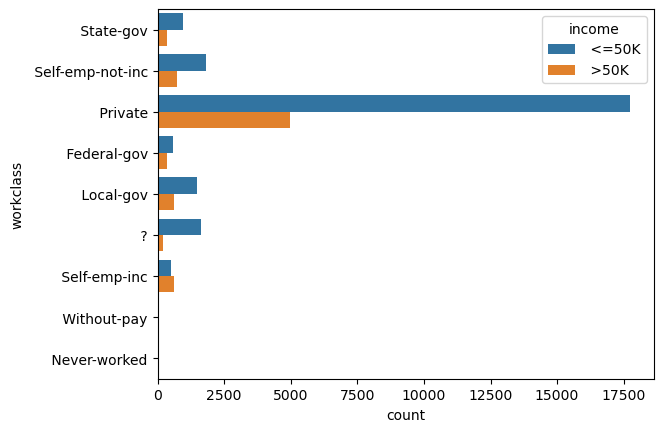

In [19]:
sns.countplot(y=base_adult["workclass"], hue=base_adult["income"])

In [21]:
scipy.stats.contingency.association(pd.crosstab(index=base_adult["workclass"], columns=base_adult["income"]))

0.1792076202095948

In [22]:
scipy.stats.contingency.association(pd.crosstab(index=base_adult["workclass"], columns=base_adult["income"]),
                                    method="tschuprow")

0.10655748850797778

In [23]:
pd.crosstab(index=base_adult["workclass"], columns=base_adult["income"])

income,<=50K,>50K
workclass,,
?,1645,191
Federal-gov,589,371
Local-gov,1476,617
Never-worked,7,0
Private,17733,4963
Self-emp-inc,494,622
Self-emp-not-inc,1817,724
State-gov,945,353
Without-pay,14,0


Dropping values `?` from dataset

In [24]:
base_adult[base_adult.workclass == " ?"]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
27,0.506849,?,180211,Some-college,10,Married-civ-spouse,?,Husband,Asian-Pac-Islander,Male,0,0,60,South,>50K
61,0.205479,?,293936,7th-8th,4,Married-spouse-absent,?,Not-in-family,White,Male,0,0,40,?,<=50K
69,0.109589,?,200681,Some-college,10,Never-married,?,Own-child,White,Male,0,0,40,United-States,<=50K
77,0.684932,?,212759,10th,6,Married-civ-spouse,?,Husband,White,Male,0,0,2,United-States,<=50K
106,0.000000,?,304873,10th,6,Never-married,?,Own-child,White,Female,34095,0,32,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32530,0.246575,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K
32531,0.178082,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
32539,0.739726,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K
32541,0.328767,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [25]:
base_adult.drop(base_adult.loc[base_adult.workclass == " ?"].index, inplace=True)

In [26]:
base_adult.drop(base_adult.loc[base_adult.occupation == " ?"].index, inplace=True)

In [27]:
np.unique(base_adult["occupation"], return_counts=True)

(array([' Adm-clerical', ' Armed-Forces', ' Craft-repair',
        ' Exec-managerial', ' Farming-fishing', ' Handlers-cleaners',
        ' Machine-op-inspct', ' Other-service', ' Priv-house-serv',
        ' Prof-specialty', ' Protective-serv', ' Sales', ' Tech-support',
        ' Transport-moving'], dtype=object),
 array([3770,    9, 4099, 4066,  994, 1370, 2002, 3295,  149, 4140,  649,
        3650,  928, 1597]))

In [28]:
np.unique(base_adult["workclass"], return_counts=True)

(array([' Federal-gov', ' Local-gov', ' Private', ' Self-emp-inc',
        ' Self-emp-not-inc', ' State-gov', ' Without-pay'], dtype=object),
 array([  960,  2093, 22696,  1116,  2541,  1298,    14]))

In [29]:
np.unique(base_adult["capital-loss"], return_counts=True)

(array([   0,  155,  213,  323,  419,  625,  653,  810,  880,  974, 1092,
        1138, 1258, 1340, 1380, 1408, 1411, 1485, 1504, 1539, 1564, 1573,
        1579, 1590, 1594, 1602, 1617, 1628, 1648, 1651, 1668, 1669, 1672,
        1719, 1721, 1726, 1735, 1740, 1741, 1755, 1762, 1816, 1825, 1844,
        1848, 1876, 1887, 1902, 1944, 1974, 1977, 1980, 2001, 2002, 2042,
        2051, 2057, 2080, 2129, 2149, 2174, 2179, 2201, 2205, 2206, 2231,
        2238, 2246, 2258, 2267, 2282, 2339, 2352, 2377, 2392, 2415, 2444,
        2457, 2467, 2472, 2547, 2559, 2603, 2754, 2824, 3004, 3683, 3770,
        3900, 4356]),
 array([29257,     1,     4,     3,     1,    12,     3,     2,     6,
            2,     7,     2,     3,     7,     7,    21,     1,    48,
           16,     1,    25,     6,    20,    39,     8,    35,     9,
           14,     2,     9,     3,    24,    34,    20,    16,     4,
            2,    42,    23,     2,    13,     2,     3,     1,    50,
           39,   157,   199,   

In [30]:
np.unique_counts(base_adult[base_adult["capital-loss"] == 0]["income"])

UniqueCountsResult(values=array([' <=50K', ' >50K'], dtype=object), counts=array([22364,  6893]))

In [31]:
np.unique_counts(base_adult[base_adult["capital-loss"] != 0]["income"])

UniqueCountsResult(values=array([' <=50K', ' >50K'], dtype=object), counts=array([704, 757]))

In [32]:
np.unique(base_adult["capital-gain"], return_counts=True)

(array([    0,   114,   401,   594,   914,   991,  1055,  1086,  1151,
         1173,  1409,  1424,  1455,  1471,  1506,  1639,  1797,  1831,
         1848,  2009,  2036,  2050,  2062,  2105,  2174,  2176,  2202,
         2228,  2290,  2329,  2346,  2354,  2387,  2407,  2414,  2463,
         2538,  2580,  2597,  2635,  2653,  2829,  2885,  2907,  2936,
         2961,  2964,  2977,  2993,  3103,  3137,  3273,  3325,  3411,
         3418,  3432,  3456,  3464,  3471,  3674,  3781,  3818,  3887,
         3908,  3942,  4064,  4101,  4386,  4416,  4508,  4650,  4687,
         4787,  4865,  4931,  4934,  5013,  5060,  5178,  5455,  5556,
         5721,  6097,  6360,  6418,  6497,  6514,  6723,  6767,  6849,
         7298,  7430,  7443,  7688,  7896,  7978,  8614,  9386,  9562,
        10520, 10566, 10605, 11678, 13550, 14084, 14344, 15020, 15024,
        15831, 18481, 20051, 22040, 25124, 25236, 27828, 34095, 41310,
        99999]),
 array([28129,     6,     1,    29,     8,     3,    21,    

In [33]:
np.unique_counts(base_adult[base_adult["capital-gain"] == 0]["income"])

UniqueCountsResult(values=array([' <=50K', ' >50K'], dtype=object), counts=array([22109,  6020]))

In [34]:
np.unique_counts(base_adult[base_adult["capital-gain"] != 0]["income"])

UniqueCountsResult(values=array([' <=50K', ' >50K'], dtype=object), counts=array([ 959, 1630]))

In [35]:
base_adult = drop_unnecessary(base_adult)
base_adult

,age,workclass,fnlwgt,education-num,occupation,hours-per-week,income
0,0.301370,State-gov,77516,13,Adm-clerical,40,<=50K
1,0.452055,Self-emp-not-inc,83311,13,Exec-managerial,13,<=50K
2,0.287671,Private,215646,9,Handlers-cleaners,40,<=50K
3,0.493151,Private,234721,7,Handlers-cleaners,40,<=50K
4,0.150685,Private,338409,13,Prof-specialty,40,<=50K
...,...,...,...,...,...,...,...
32556,0.136986,Private,257302,12,Tech-support,38,<=50K
32557,0.315068,Private,154374,9,Machine-op-inspct,40,>50K
32558,0.561644,Private,151910,9,Adm-clerical,40,<=50K
32559,0.068493,Private,201490,9,Adm-clerical,20,<=50K


In [36]:
base_adult = pd.get_dummies(base_adult, columns=["workclass", "occupation"], dtype=float)
base_adult

,age,fnlwgt,education-num,hours-per-week,income,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving
0,0.301370,77516,13,40,<=50K,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.452055,83311,13,13,<=50K,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.287671,215646,9,40,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.493151,234721,7,40,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.150685,338409,13,40,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.136986,257302,12,38,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32557,0.315068,154374,9,40,>50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32558,0.561644,151910,9,40,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32559,0.068493,201490,9,20,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [37]:
fnlwgt_scaler = MinMaxScaler()
base_adult["fnlwgt"] = fnlwgt_scaler.fit_transform(pd.DataFrame(base_adult["fnlwgt"]))

edu_scaler = MinMaxScaler()
base_adult["education-num"] = edu_scaler.fit_transform(pd.DataFrame(base_adult["education-num"]))

hours_scaler = MinMaxScaler()
base_adult["hours-per-week"] = hours_scaler.fit_transform(pd.DataFrame(base_adult["hours-per-week"]))

base_adult

,age,fnlwgt,education-num,hours-per-week,income,workclass_ Federal-gov,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,...,occupation_ Farming-fishing,occupation_ Handlers-cleaners,occupation_ Machine-op-inspct,occupation_ Other-service,occupation_ Priv-house-serv,occupation_ Prof-specialty,occupation_ Protective-serv,occupation_ Sales,occupation_ Tech-support,occupation_ Transport-moving
0,0.301370,0.043338,0.800000,0.397959,<=50K,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.452055,0.047277,0.800000,0.122449,<=50K,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.287671,0.137244,0.533333,0.397959,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.493151,0.150212,0.400000,0.397959,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.150685,0.220703,0.800000,0.397959,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.136986,0.165563,0.733333,0.377551,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
32557,0.315068,0.095589,0.533333,0.397959,>50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32558,0.561644,0.093914,0.533333,0.397959,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
32559,0.068493,0.127620,0.533333,0.193878,<=50K,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [38]:
X = base_adult.drop(columns=["income"])
y = base_adult["income"]

In [39]:
income_replacer = {" <=50K": 0, " >50K": 1}
y.replace(income_replacer, inplace=True)

C:\Users\User\AppData\Local\Temp\ipykernel_33420\3940048061.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y.replace(income_replacer, inplace=True)


In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [41]:
neigh_class = KNeighborsClassifier()
neigh_class.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [42]:
#tree_clf = DecisionTreeClassifier(random_state=0)

In [43]:
#cross_val_score(tree_clf, X, y, cv=10)
#tree_clf.fit(X=X, y=y)